In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/car data.csv')
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Exploratory Data Analysis (EDA)

Let's start by getting a general overview of the dataset, including its shape, data types, and checking for any missing values.

In [3]:
print('DataFrame Shape:', df.shape)
print('\nDataFrame Info:')
df.info()

DataFrame Shape: (301, 9)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Next, let's look at the descriptive statistics for the numerical columns to understand their distribution, central tendency, and spread.

In [4]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Now, let's identify if there are any missing values in the dataset.

In [5]:
print('\nMissing Values:')
display(df.isnull().sum())


Missing Values:


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


### Categorical Features Analysis

Let's examine the unique values and their counts for the categorical columns to understand their distribution.

In [6]:
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

for col in categorical_cols:
    print(f'\nUnique values and counts for {col}:')
    display(df[col].value_counts())
    print('-' * 30)


Unique values and counts for Fuel_Type:


,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


------------------------------

Unique values and counts for Seller_Type:


,count
Seller_Type,
Dealer,195
Individual,106


------------------------------

Unique values and counts for Transmission:


,count
Transmission,
Manual,261
Automatic,40


------------------------------

Unique values and counts for Owner:


,count
Owner,
0,290
1,10
3,1


------------------------------


The `Car_Name` column has too many unique values to display here effectively. We'll explore it later if needed, perhaps by looking at the most common car names or their impact on prices.

### Data Visualization

Now, let's create some visualizations to better understand the distributions and relationships within the data. We'll start with distributions of key numerical features and then look at categorical features.

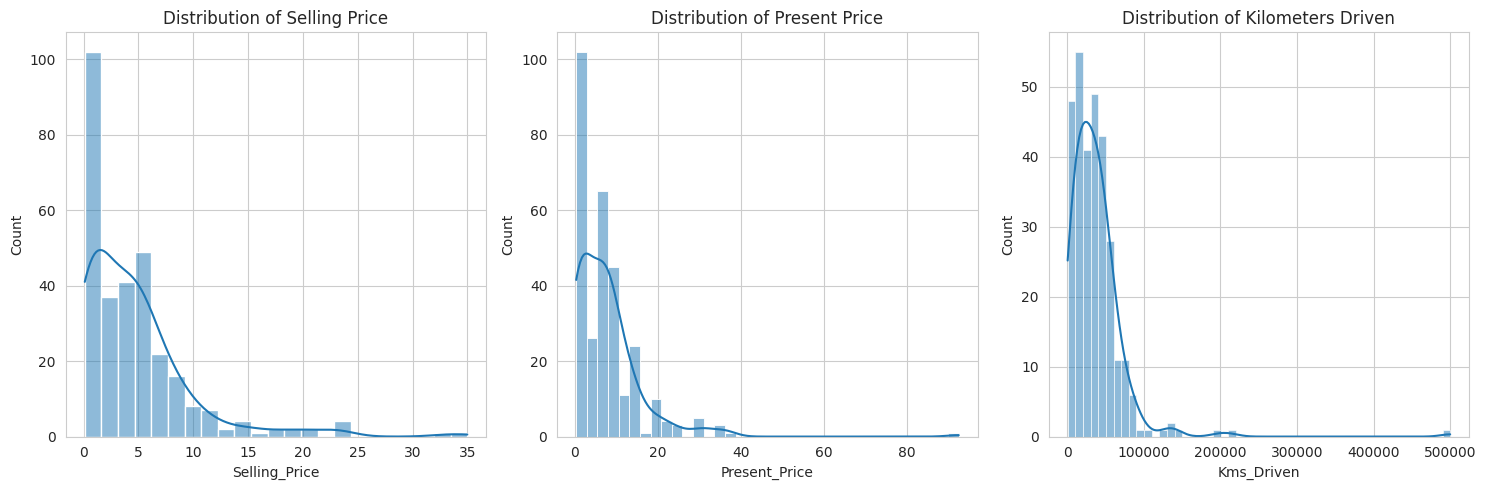

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')

plt.subplot(1, 3, 2)
sns.histplot(df['Present_Price'], kde=True)
plt.title('Distribution of Present Price')

plt.subplot(1, 3, 3)
sns.histplot(df['Kms_Driven'], kde=True)
plt.title('Distribution of Kilometers Driven')

plt.tight_layout()
plt.show()

Let's also visualize the distributions of our categorical variables using count plots.

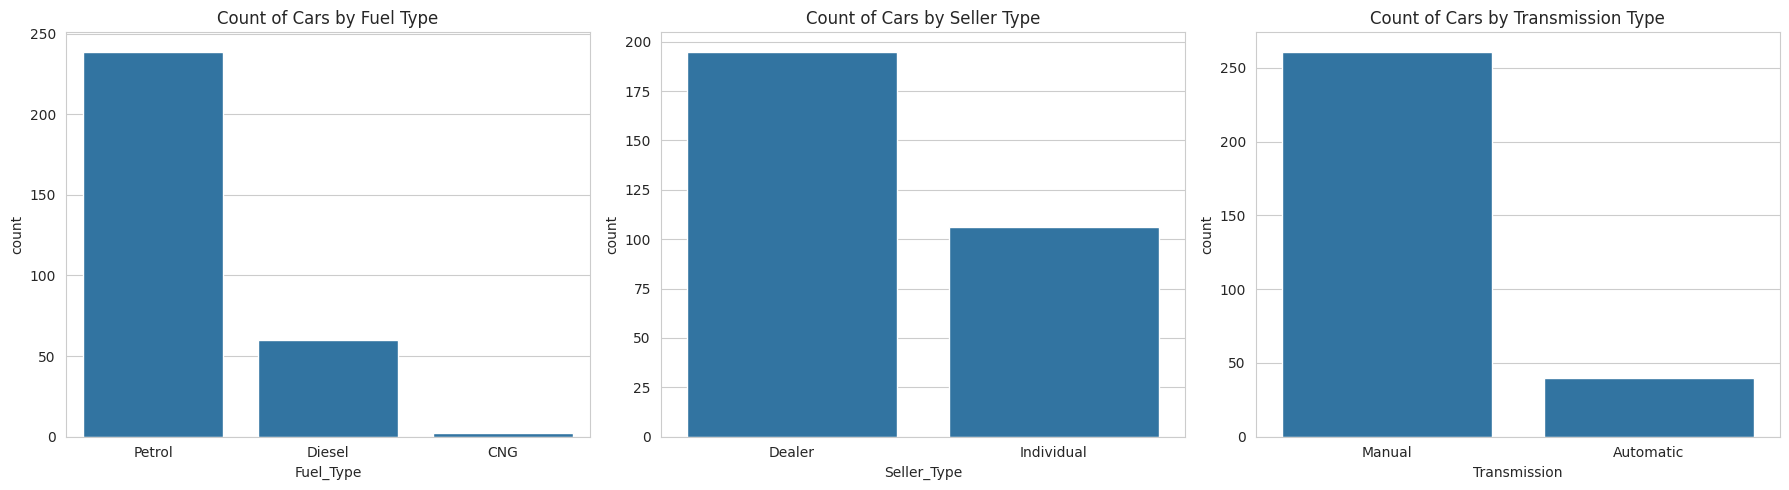

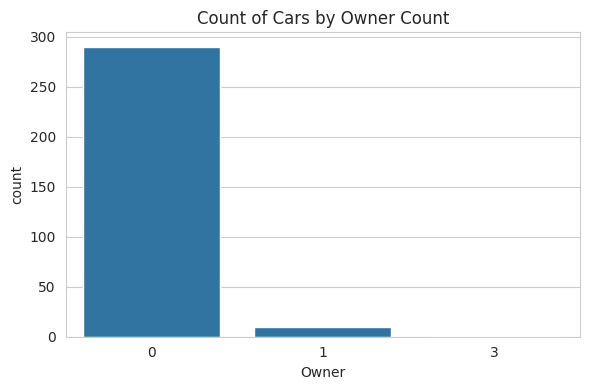

In [8]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Fuel_Type')
plt.title('Count of Cars by Fuel Type')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Seller_Type')
plt.title('Count of Cars by Seller Type')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='Transmission')
plt.title('Count of Cars by Transmission Type')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Owner')
plt.title('Count of Cars by Owner Count')
plt.tight_layout()
plt.show()

### Correlation Analysis

Let's examine the correlation between the numerical variables, especially with `Selling_Price`, to identify potential relationships.

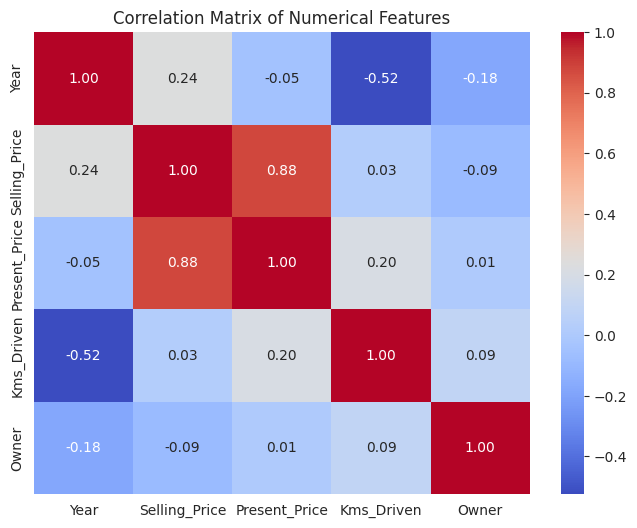

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Bivariate Analysis: Selling Price vs. Other Features

Now, let's visualize how `Selling_Price` is affected by other key features, starting with numerical ones.

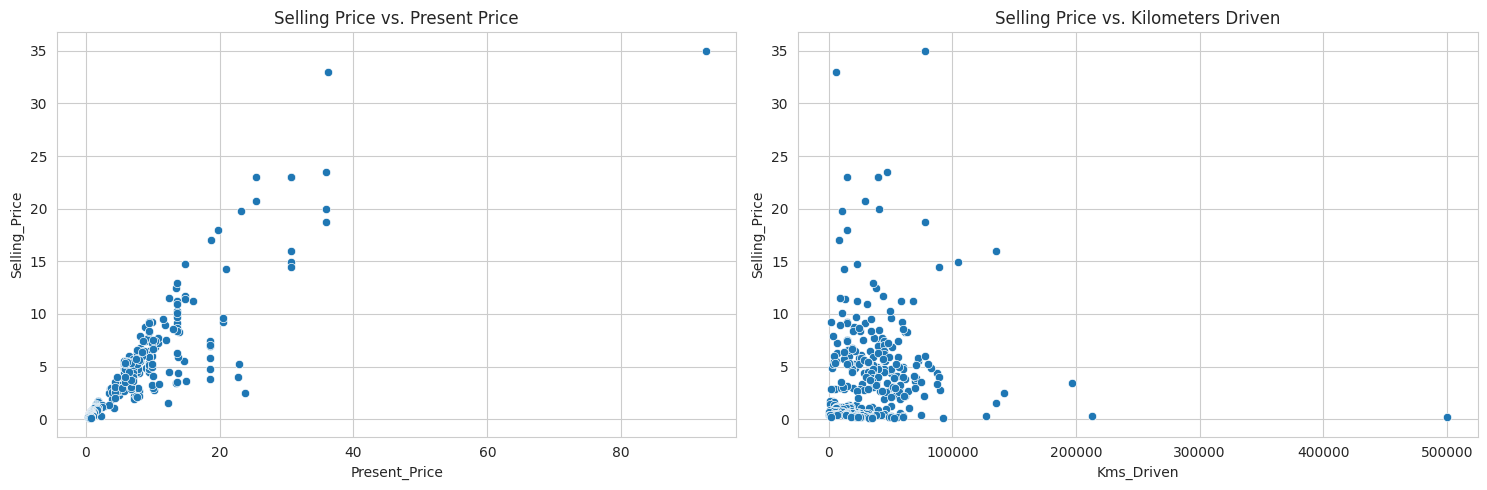

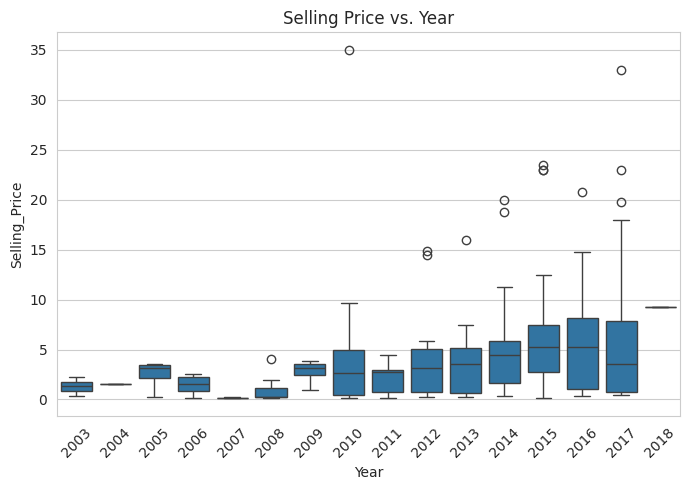

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price')
plt.title('Selling Price vs. Present Price')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price')
plt.title('Selling Price vs. Kilometers Driven')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Year', y='Selling_Price')
plt.title('Selling Price vs. Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let's also look at `Selling_Price` in relation to categorical features.

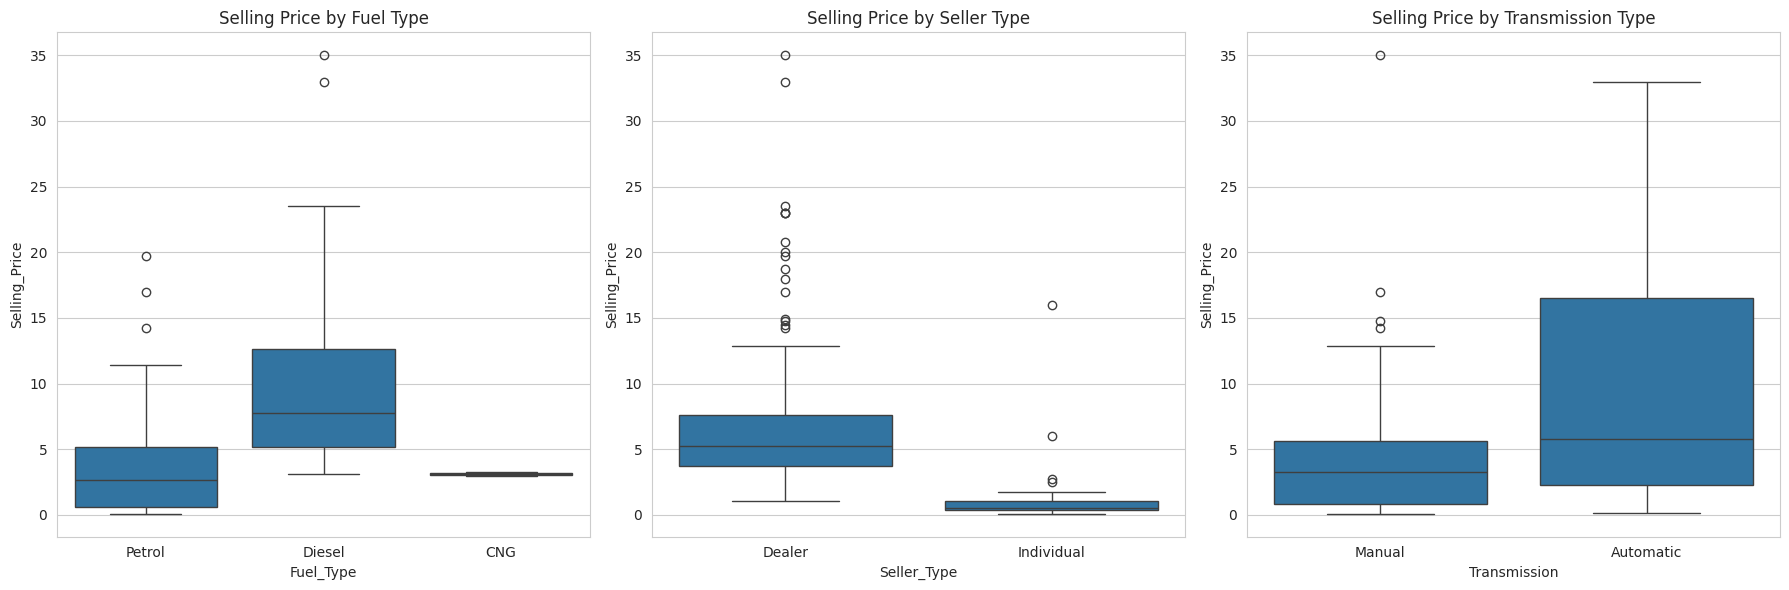

In [11]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Selling Price by Fuel Type')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Seller_Type', y='Selling_Price')
plt.title('Selling Price by Seller Type')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Transmission', y='Selling_Price')
plt.title('Selling Price by Transmission Type')

plt.tight_layout()
plt.show()

### Data Preprocessing for Linear Regression

Before building the model, we need to convert categorical features into numerical format using one-hot encoding. We will also drop `Car_Name` as it has too many unique values and `Owner` as it was highly skewed (mostly 0 owners).

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

# Drop Car_Name and Owner, as discussed in EDA
df_processed = df.drop(columns=['Car_Name', 'Owner'])

# Convert categorical features to numerical using one-hot encoding
df_processed = pd.get_dummies(df_processed, drop_first=True)

display(df_processed.head())

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,False,True,False,True
1,2013,4.75,9.54,43000,True,False,False,True
2,2017,7.25,9.85,6900,False,True,False,True
3,2011,2.85,4.15,5200,False,True,False,True
4,2014,4.60,6.87,42450,True,False,False,True


### Splitting Data into Training and Testing Sets

Now, we'll separate the features (X) from the target variable (y), which is `Selling_Price`. Then, we'll split the data into training and testing sets to train and evaluate our model.

In [13]:
X = df_processed.drop('Selling_Price', axis=1)
y = df_processed['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (240, 7)
Shape of X_test: (61, 7)
Shape of y_train: (240,)
Shape of y_test: (61,)


### Training the Linear Regression Model

We will now train a Linear Regression model using the training data.

In [14]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

print('Training of Linear Regression model complete.')

Training of Linear Regression model complete.


### Model Evaluation

Let's evaluate the performance of our Linear Regression model on the test set using various metrics such as R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [17]:
y_pred = lin_reg_model.predict(X_test)

print('R-squared:', metrics.r2_score(y_test, y_pred))
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R-squared: 0.854129095376433
Mean Absolute Error (MAE): 1.1872186431099836
Mean Squared Error (MSE): 3.360221552507374
Root Mean Squared Error (RMSE): 1.8330907103870704


### Visualizing Predictions vs. Actual Values

Let's plot the predicted `Selling_Price` against the actual `Selling_Price` from the test set to visually inspect the model's performance.

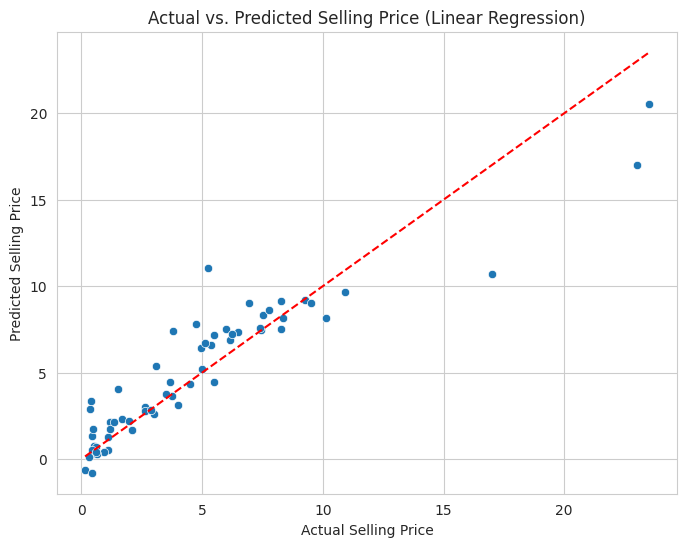

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Selling Price (Linear Regression)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Ideal line
plt.show()

### Histogram of Prediction Errors (Residuals)

Let's visualize the distribution of the errors (residuals) made by our linear regression model. Ideally, these errors should be normally distributed around zero.

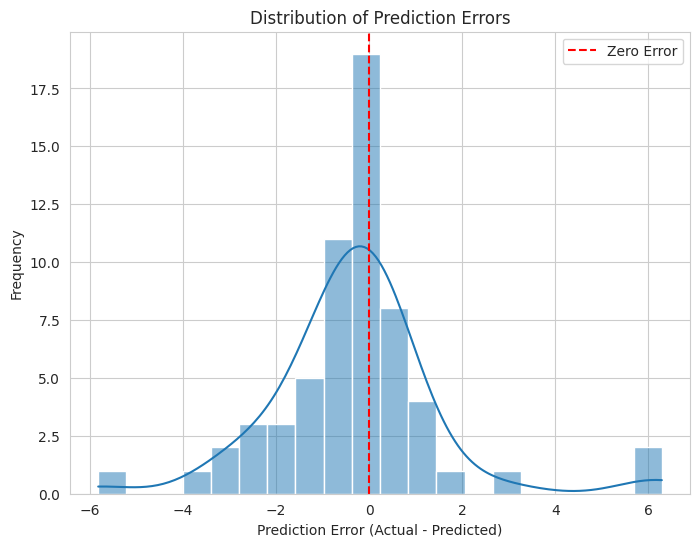

In [18]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(errors, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()